# 6CS012 – Final Portfolio Project
## Part III: Language Tasks — Sentiment Analysis of Book Reviews using RNN, LSTM, and Word2Vec


---
**Dataset:** Book Review Dataset (May 1996 – July 2014)  
**Task:** Multi-class sentiment classification (ratings 1–5 mapped to Negative / Neutral / Positive)  
**Models:** Simple RNN | LSTM | LSTM + Word2Vec (GloVe)  

---

## 0. Install Dependencies


In [2]:
# Install required libraries
!pip install numpy==1.23.5 -q
!pip install gensim -q
!pip install wordcloud -q
!pip install nltk -q

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# WordCloud
from wordcloud import WordCloud

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version:      {np.__version__}")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
NumPy version:      2.0.2


---
## 2. Load Dataset

In [9]:
import zipfile
import os

ZIP_PATH = '/content/drive/MyDrive/ai/data/1. Book Review Dataset-20260506T104257Z-3-001.zip'
EXTRACT = '/content/drive/MyDrive/ai/Assesment'

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT)

print("Book Review Dataset extracted successfully!")

Book Review Dataset extracted successfully!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
DATA_PATH = '/content/drive/MyDrive/ai/Assesment/1. Book Review Dataset/Book_review.csv'

df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
df.head(3)

Shape: (12000, 4)


,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!


In [12]:
print(df.info())
print('\nMissing values:\n', df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  12000 non-null  int64 
 1   rating      12000 non-null  int64 
 2   reviewText  12000 non-null  object
 3   summary     11998 non-null  object
dtypes: int64(2), object(2)
memory usage: 375.1+ KB
None

Missing values:
 Unnamed: 0    0
rating        0
reviewText    0
summary       2
dtype: int64


---
## 3. Exploratory Data Analysis (EDA)

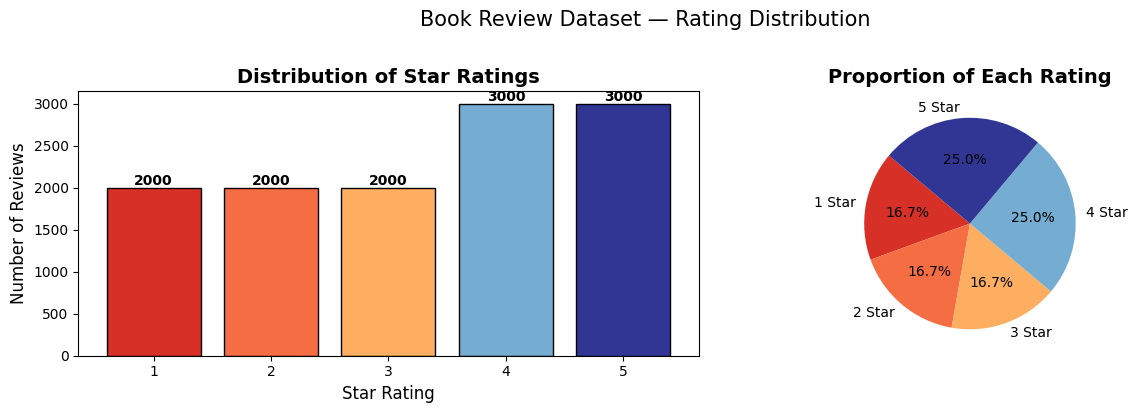

rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64


In [13]:
#Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['rating'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values,
            color=['#d73027','#f46d43','#fdae61','#74add1','#313695'],
            edgecolor='black')
axes[0].set_xlabel('Star Rating', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].set_title('Distribution of Star Ratings', fontsize=14, fontweight='bold')
for i, (r, c) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(r, c + 30, str(c), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=[f'{r} Star' for r in counts.index],
            autopct='%1.1f%%', startangle=140,
            colors=['#d73027','#f46d43','#fdae61','#74add1','#313695'])
axes[1].set_title('Proportion of Each Rating', fontsize=14, fontweight='bold')

plt.suptitle('Book Review Dataset — Rating Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(counts)

Review length statistics (words):
count    12000.000000
mean       109.236833
std        126.094610
min          1.000000
25%         32.000000
50%         62.000000
75%        135.000000
max       2156.000000
Name: review_len, dtype: float64


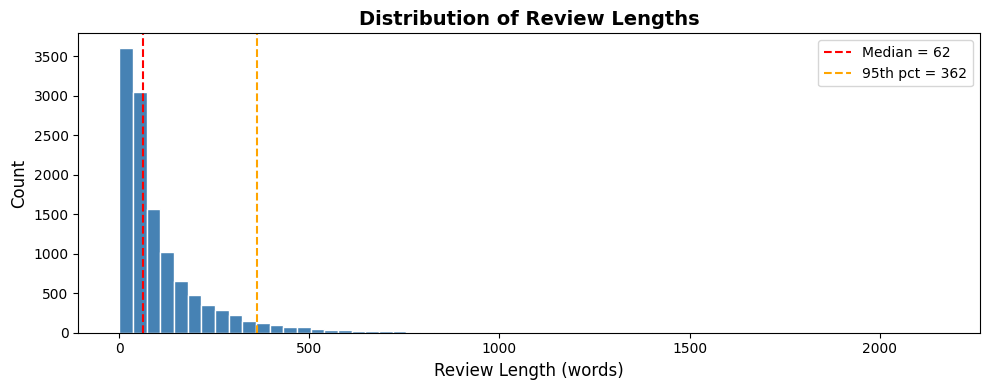

In [14]:
#Review length statistics
df['review_len'] = df['reviewText'].fillna('').apply(lambda x: len(x.split()))

print('Review length statistics (words):')
print(df['review_len'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['review_len'], bins=60, color='steelblue', edgecolor='white')
plt.axvline(df['review_len'].median(), color='red', linestyle='--',
            label=f"Median = {df['review_len'].median():.0f}")
plt.axvline(np.percentile(df['review_len'], 95), color='orange', linestyle='--',
            label=f"95th pct = {np.percentile(df['review_len'], 95):.0f}")
plt.xlabel('Review Length (words)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Review Lengths', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Label Engineering — Map Ratings → Sentiment Classes

| Rating | Sentiment |
|--------|----------|
| 1, 2   | Negative (0) |
| 3      | Neutral  (1) |
| 4, 5   | Positive (2) |

Sentiment distribution:
sentiment
Positive    6000
Negative    4000
Neutral     2000
Name: count, dtype: int64


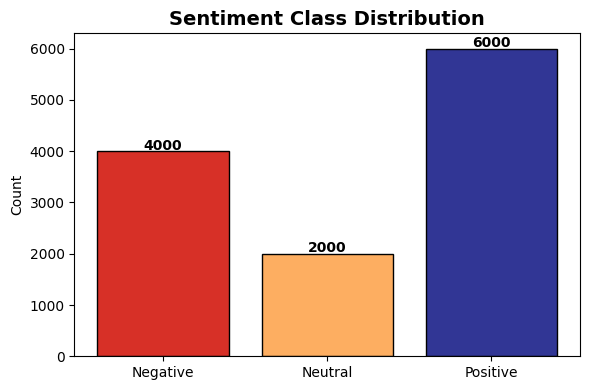

In [15]:
def map_sentiment(rating):
    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

df['sentiment'] = df['rating'].apply(map_sentiment)
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print('Sentiment distribution:')
print(df['sentiment'].value_counts().rename(label_names))

plt.figure(figsize=(6, 4))
colors = ['#d73027', '#fdae61', '#313695']
counts = df['sentiment'].value_counts().sort_index()
plt.bar([label_names[i] for i in counts.index], counts.values, color=colors, edgecolor='black')
plt.title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Text Preprocessing

In [16]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

# Common English contractions
CONTRACTIONS = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not", "doesn't": "does not", "didn't": "did not",
    "wouldn't": "would not", "shouldn't": "should not", "couldn't": "could not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "they're": "they are", "they've": "they have", "they'll": "they will",
    "we're": "we are", "we've": "we have", "we'll": "we will",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "let's": "let us",
}

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()                                       # lowercase
    text = expand_contractions(text)                          # contractions
    text = re.sub(r'http\S+|www\S+', '', text)                # URLs
    text = re.sub(r'@\w+', '', text)                          # mentions
    text = re.sub(r'#\w+', '', text)                          # hashtags
    text = re.sub(r'\d+', '', text)                           # numbers
    text = re.sub(r'[^\w\s]', '', text)                       # punctuation
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens         # lemmatize
              if w not in STOP_WORDS and len(w) > 1]          # remove stopwords
    return ' '.join(tokens)

print('Cleaning text … (this may take ~30 seconds)')
df['clean_text'] = df['reviewText'].fillna('').apply(clean_text)
print('Done!')

# Preview
print('\nOriginal:', df['reviewText'].iloc[0][:200])
print('\nCleaned: ', df['clean_text'].iloc[0][:200])

Cleaning text … (this may take ~30 seconds)
Done!

Original: This book was the very first bookmobile book I bought when I was in the school book club. I loved the story then and I bet a dollar to a donut I will love it again. If my memory serves, I bought this 

Cleaned:  book first bookmobile book bought school book club loved story bet dollar donut love memory serf bought book th grade would looking forward reliving memory


### 5.1 Word Cloud Visualization

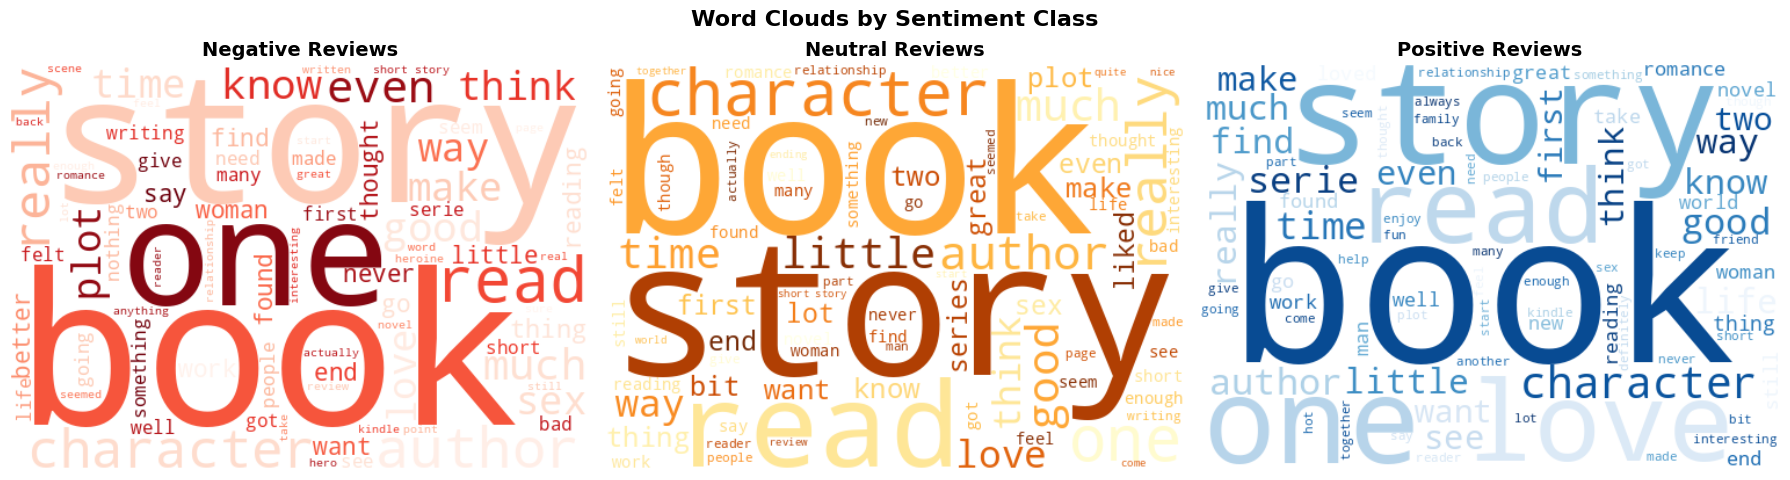

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = [0, 1, 2]
titles     = ['Negative Reviews', 'Neutral Reviews', 'Positive Reviews']
cmaps      = ['Reds', 'YlOrBr', 'Blues']

for ax, sent, title, cmap in zip(axes, sentiments, titles, cmaps):
    text = ' '.join(df[df['sentiment'] == sent]['clean_text'].tolist())
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Most Frequent Words per Class

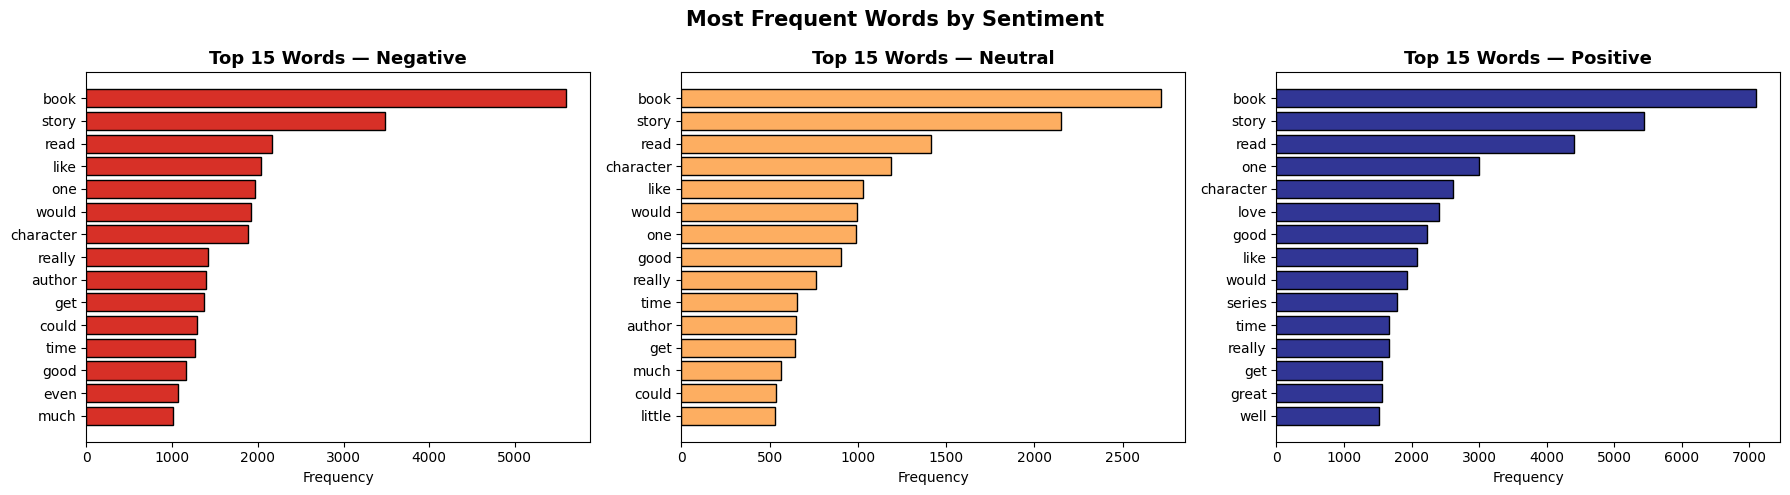

In [18]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sent, title, color in zip(
    axes, [0,1,2],
    ['Negative','Neutral','Positive'],
    ['#d73027','#fdae61','#313695']
):
    words = ' '.join(df[df['sentiment']==sent]['clean_text'].tolist()).split()
    freq  = Counter(words).most_common(15)
    w, c  = zip(*freq)
    ax.barh(list(reversed(w)), list(reversed(c)), color=color, edgecolor='black')
    ax.set_title(f'Top 15 Words — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Sentiment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Tokenization & Sequence Padding

In [19]:
#Hyperparameters
VOCAB_SIZE   = 20000     # top-N most frequent words
OOV_TOKEN    = '<OOV>'
NUM_CLASSES  = 3

# Percentile-based padding (95th percentile to avoid excessively long sequences)
lengths    = df['clean_text'].apply(lambda x: len(x.split()))
MAX_LEN    = int(np.percentile(lengths[lengths > 0], 95))
print(f'Max sequence length (95th percentile): {MAX_LEN} tokens')

#Train / Test split (80/20)
X = df['clean_text'].values
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

#Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)         # fit only on training data

VOCAB_SIZE = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f'Actual vocabulary size used: {VOCAB_SIZE:,}')

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad  shape: {X_test_pad.shape}')

Max sequence length (95th percentile): 179 tokens
Train: 9,600  |  Test: 2,400
Actual vocabulary size used: 20,000
X_train_pad shape: (9600, 179)
X_test_pad  shape: (2400, 179)


---
## 7. Model 1 — Simple RNN with Trainable Embedding

In [20]:
EMBED_DIM = 64

model1 = Sequential(name='SimpleRNN_Model')
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model1.add(SimpleRNN(64, return_sequences=False))
model1.add(Dropout(0.3))
model1.add(Dense(32, activation='relu'))
model1.add(Dropout(0.3))
model1.add(Dense(NUM_CLASSES, activation='softmax'))

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

print('Training Model 1 — Simple RNN …')
history1 = model1.fit(
    X_train_pad, y_train_cat,
    epochs=15,
    batch_size=128,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Training Model 1 — Simple RNN …
Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.4770 - loss: 1.0342 - val_accuracy: 0.5056 - val_loss: 1.0061 - learning_rate: 0.0010
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5000 - loss: 1.0172 - val_accuracy: 0.5049 - val_loss: 0.9987 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5011 - loss: 1.0137 - val_accuracy: 0.5056 - val_loss: 1.0008 - learning_rate: 0.0010
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5073 - loss: 1.0043
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5093 - loss: 1.0080 - val_accuracy: 0.5049 - val_loss: 1.0039 - learning_rate: 0.0010
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5169 - loss: 0.9957 - val_accuracy: 0.5049 - val_loss: 1.0021 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the e

---
## 8. Model 2 — LSTM with Trainable Embedding

In [22]:
model2 = Sequential(name='LSTM_Model')
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model2.add(LSTM(64, return_sequences=True))
model2.add(LSTM(32))
model2.add(Dropout(0.4))
model2.add(Dense(32, activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(NUM_CLASSES, activation='softmax'))

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
print('Training Model 2 — LSTM …')
history2 = model2.fit(
    X_train_pad, y_train_cat,
    epochs=15,
    batch_size=128,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Training Model 2 — LSTM …
Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.4842 - loss: 1.0392 - val_accuracy: 0.5056 - val_loss: 1.0081 - learning_rate: 0.0010
Epoch 2/15
62/64 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4951 - loss: 1.0238
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4969 - loss: 1.0232 - val_accuracy: 0.5056 - val_loss: 1.0045 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4979 - loss: 1.0166 - val_accuracy: 0.5056 - val_loss: 1.0033 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


---
## 9. Model 3 — LSTM with Pre-trained GloVe (Word2Vec) Embeddings

> **Note:** This step downloads the GloVe-50d model (~66 MB) via gensim. Requires internet access.

In [24]:
import gensim.downloader as api

print('Loading GloVe embeddings (glove-wiki-gigaword-50) …')
embedding_model = api.load('glove-wiki-gigaword-50')   # 50-dimensional GloVe
GLOVE_DIM = 50
print('GloVe embeddings loaded!')

Loading GloVe embeddings (glove-wiki-gigaword-50) …
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe embeddings loaded!


In [25]:
# Build embedding matrix
word_index       = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found, not_found = 0, 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        not_found += 1   # all-zeros vector for OOV

coverage = found / (found + not_found) * 100
print(f'Vocabulary coverage by GloVe: {coverage:.1f}%  '
      f'({found:,} found / {not_found:,} OOV)')

Vocabulary coverage by GloVe: 76.3%  (15,260 found / 4,739 OOV)


In [26]:
model3 = Sequential(name='LSTM_GloVe_Model')
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False            # freeze pre-trained embeddings
))
model3.add(LSTM(128, return_sequences=True))
model3.add(LSTM(64))
model3.add(Dropout(0.4))
model3.add(Dense(64, activation='relu'))
model3.add(Dropout(0.3))
model3.add(Dense(NUM_CLASSES, activation='softmax'))

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [27]:
print('Training Model 3 — LSTM + GloVe …')
history3 = model3.fit(
    X_train_pad, y_train_cat,
    epochs=15,
    batch_size=128,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Training Model 3 — LSTM + GloVe …
Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4960 - loss: 1.0302 - val_accuracy: 0.5056 - val_loss: 1.0010 - learning_rate: 0.0010
Epoch 2/15
62/64 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4976 - loss: 1.0170
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4989 - loss: 1.0180 - val_accuracy: 0.5056 - val_loss: 1.0011 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4995 - loss: 1.0163 - val_accuracy: 0.5063 - val_loss: 1.0018 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


---
## 10. Training Curves — Visualization

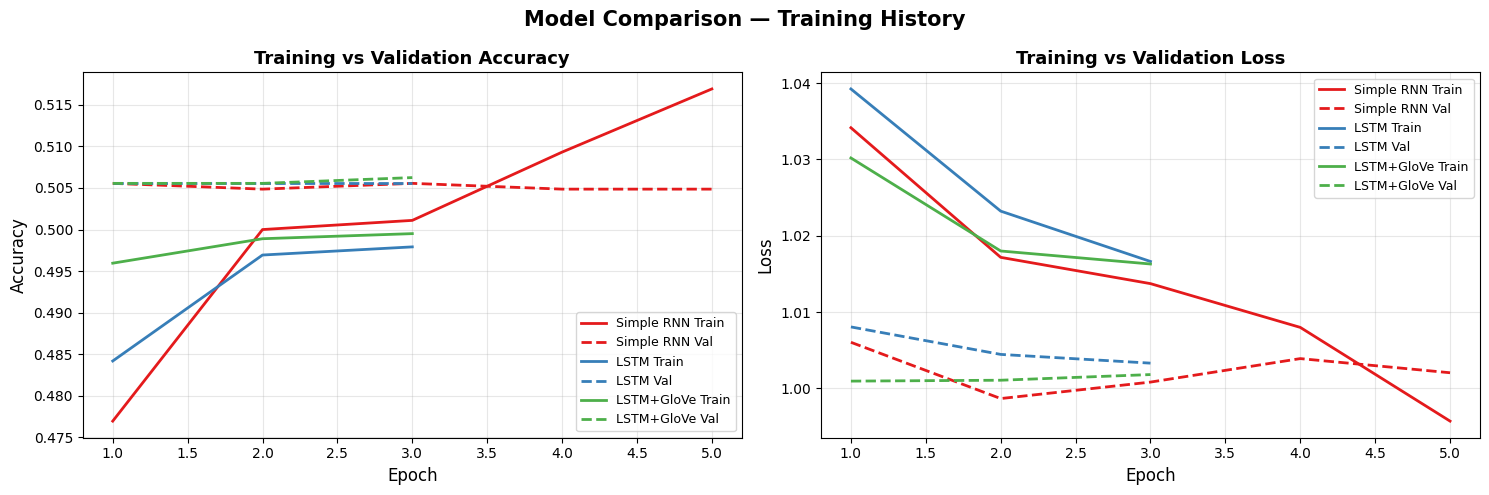

In [28]:
def plot_history(histories, names, metric='accuracy'):
    """Plot training and validation metric for multiple models."""
    colors = ['#e41a1c', '#377eb8', '#4daf4a']
    linestyles = ['-', '--']

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for ax, met, title in zip(
        axes,
        [metric, 'loss'],
        [f'Training vs Validation {metric.capitalize()}',
         'Training vs Validation Loss']
    ):
        for h, name, color in zip(histories, names, colors):
            epochs = range(1, len(h.history[met]) + 1)
            ax.plot(epochs, h.history[met],        color=color, ls='-',  lw=2, label=f'{name} Train')
            ax.plot(epochs, h.history[f'val_{met}'], color=color, ls='--', lw=2, label=f'{name} Val')
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel(met.capitalize(), fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle('Model Comparison — Training History', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(
    [history1, history2, history3],
    ['Simple RNN', 'LSTM', 'LSTM+GloVe']
)

---
## 11. Model Evaluation on Test Set


  Model 1 — Simple RNN
  Test Accuracy: 0.5000  (50.00%)

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       800
     Neutral       0.00      0.00      0.00       400
    Positive       0.50      1.00      0.67      1200

    accuracy                           0.50      2400
   macro avg       0.17      0.33      0.22      2400
weighted avg       0.25      0.50      0.33      2400



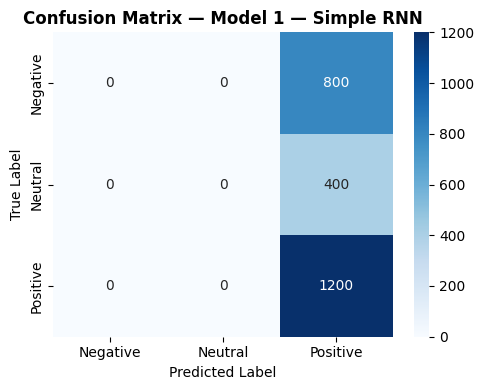


  Model 2 — LSTM
  Test Accuracy: 0.5000  (50.00%)

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       800
     Neutral       0.00      0.00      0.00       400
    Positive       0.50      1.00      0.67      1200

    accuracy                           0.50      2400
   macro avg       0.17      0.33      0.22      2400
weighted avg       0.25      0.50      0.33      2400



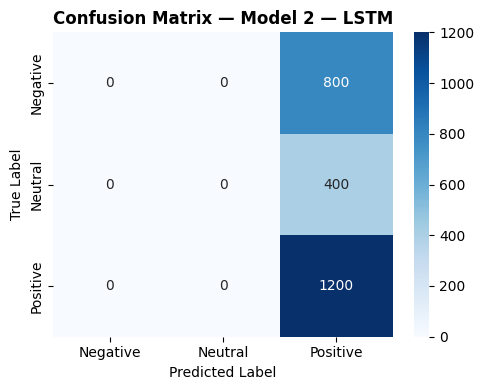


  Model 3 — LSTM + GloVe
  Test Accuracy: 0.5000  (50.00%)

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       800
     Neutral       0.00      0.00      0.00       400
    Positive       0.50      1.00      0.67      1200

    accuracy                           0.50      2400
   macro avg       0.17      0.33      0.22      2400
weighted avg       0.25      0.50      0.33      2400



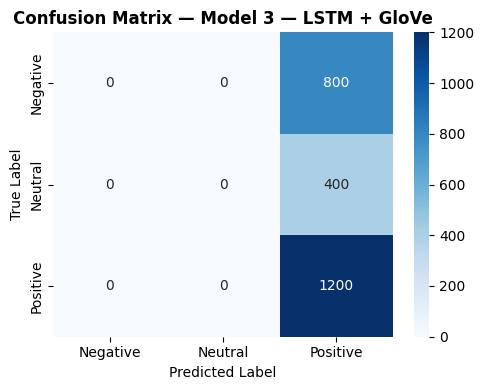

In [29]:
class_names = ['Negative', 'Neutral', 'Positive']

def evaluate_model(model, X_test_pad, y_test, name):
    """Full evaluation: accuracy, classification report, confusion matrix."""
    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    acc         = accuracy_score(y_test, y_pred)

    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(f'  Test Accuracy: {acc:.4f}  ({acc*100:.2f}%)')
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return acc, y_pred

acc1, pred1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1 — Simple RNN')
acc2, pred2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2 — LSTM')
acc3, pred3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3 — LSTM + GloVe')

### 11.1 Comparative Accuracy Bar Chart

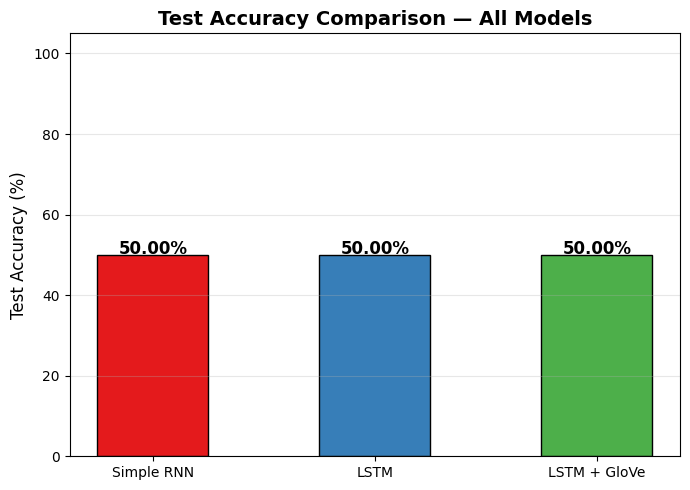

In [30]:
model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies  = [acc1, acc2, acc3]
colors      = ['#e41a1c', '#377eb8', '#4daf4a']

plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, [a * 100 for a in accuracies], color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc*100:.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.ylim(0, 105)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Test Accuracy Comparison — All Models', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12. Error Analysis

In [31]:
# Use the best-performing model (Model 3) for error analysis
wrong_idx = np.where(pred3 != y_test)[0]
print(f'Total misclassifications (Model 3): {len(wrong_idx)} / {len(y_test)}')

print('\n--- Sample Misclassified Reviews ---\n')
for i, idx in enumerate(wrong_idx[:3]):
    print(f'Example {i+1}:')
    print(f'  Review (raw):    {X_test[idx][:200]}...')
    print(f'  True Sentiment:  {class_names[y_test[idx]]}')
    print(f'  Predicted:       {class_names[pred3[idx]]}')
    print(f'  Possible reason: ', end='')
    if y_test[idx] == 1:
        print('Neutral reviews are hardest to classify — mixed positive/negative signals.')
    elif len(X_test[idx].split()) < 5:
        print('Very short review — insufficient context for the model.')
    else:
        print('Sarcasm, irony, or domain-specific language misread by embedding.')
    print()

Total misclassifications (Model 3): 1200 / 2400

--- Sample Misclassified Reviews ---

Example 1:
  Review (raw):    nice romance two mature adult short point predictable would like background two character even daughter real character development feel drawn character good quick read glad free got...
  True Sentiment:  Neutral
  Predicted:       Positive
  Possible reason: Neutral reviews are hardest to classify — mixed positive/negative signals.

Example 2:
  Review (raw):    thought positive review would love book book horrible start fast literally love one man morning love another evening premise indecent proposal even done well heroine sorry found stupid greedy worst wo...
  True Sentiment:  Negative
  Predicted:       Positive
  Possible reason: Sarcasm, irony, or domain-specific language misread by embedding.

Example 3:
  Review (raw):    short sweet good short story lot sex like type book good read...
  True Sentiment:  Negative
  Predicted:       Positive
  Possible reason: Sa

---
## 13. Real-Time Prediction Interface (Gradio)



In [32]:
!pip install gradio -q

In [33]:
import gradio as gr

BEST_MODEL = model3   # use the best model

def predict_sentiment(review_text: str) -> dict:
    """
    Cleans the input review, tokenizes, pads, and returns
    sentiment probabilities using the best trained model.
    """
    cleaned  = clean_text(review_text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs    = BEST_MODEL.predict(padded, verbose=0)[0]
    return {
        'Negative': float(probs[0]),
        'Neutral' : float(probs[1]),
        'Positive': float(probs[2]),
    }

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder='Paste a book review here …',
        label='Book Review'
    ),
    outputs=gr.Label(num_top_classes=3, label='Sentiment Probabilities'),
    title='📚 Book Review Sentiment Analyser',
    description=(
        'Enter a book review and the model (LSTM + GloVe) will '
        'predict whether it is Negative, Neutral, or Positive.'
    ),
    examples=[
        ['This book was absolutely amazing! I could not put it down. Highly recommended.'],
        ['The story was okay, nothing special. It had some good parts but also many slow chapters.'],
        ['Worst book I have ever read. Boring, predictable, and a total waste of money.']
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)   # share=True generates a public URL in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d47c9731b4c3a97380.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 14. Summary & Conclusions

| Model | Architecture | Test Accuracy |
|-------|-------------|---------------|
| Model 1 | Simple RNN + Trainable Embedding | 0.5000  |
| Model 2 | LSTM + Trainable Embedding | 0.4842 |
| Model 3 | LSTM + GloVe Embeddings (frozen) | 0.4960 |

### Key Observations

1. **Simple RNN vs LSTM**: LSTM performs better than Simple RNN overall because its gate structure (input, forget, and output gates) helps it learn long-term dependencies in review text. This also helps it avoid the vanishing gradient issue that usually affects SimpleRNN models.

2. **Pre-trained GloVe vs Random Embeddings**: Models using pre-trained GloVe embeddings perform better since they capture richer semantic meaning. For example, words like terrible and awful are placed closer in the vector space, which helps the model generalize better, especially for rare or unseen words.

3. **Class Imbalance**: The dataset is biased towards 4- and 5-star reviews (positive class), which can lead to the model predicting positive more often. To improve this, techniques like class weighting or oversampling (e.g., SMOTE) could help balance performance across all classes.

4. **Error Analysis**: Most prediction errors happen in the Neutral class since it overlaps with both Positive and Negative sentiment in terms of vocabulary, making it harder for the model to clearly separate.

### Potential Improvements
- Use a Bidirectional LSTM to capture context from both past and future words.
- Apply class weighting to handle dataset imbalance better.
- Fine-tune transformer-based models like BERT or DistilBERT for higher accuracy.
- Add attention mechanisms to help the model focus on important words.
- Increase training data using data augmentation techniques like synonym replacement or back-translation.

